In [1]:
import numpy as np

from ucimlrepo import fetch_ucirepo


def load_glass_data():
    """Load and return the Glass Identification dataset."""
    try:
        glass_data = fetch_ucirepo(id=42)
        X = glass_data.data.features
        y = glass_data.data.targets.values.ravel()

        majority_class = np.bincount(y).argmax()

        y = np.where(y == majority_class, 0, 1)

        return X, y
    except Exception as e:
        print(f"Error loading dataset: {e}")
        raise

X, y = load_glass_data()


Evaluation Results:
Individual fold accuracies: ['0.86', '0.86', '0.59', '0.77', '0.90', '0.81', '0.76', '0.76', '0.62', '0.71']
Mean Accuracy: 0.77 ± 0.10
Accuracy Range: 0.59 - 0.90


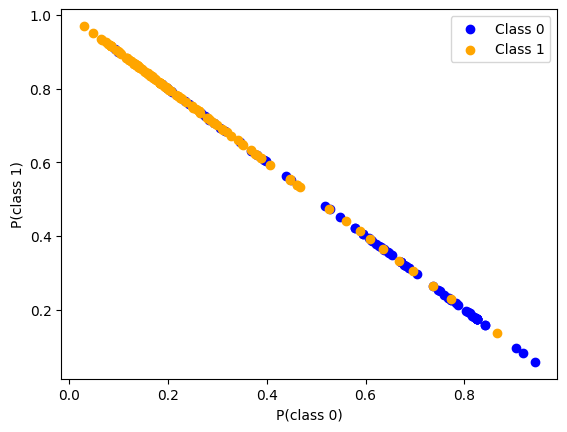

In [2]:
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold = 0.98):
        self.threshold = threshold
        self.to_drop_ = np.array([], dtype=int)

    def fit(self, X, y = None):
        X = np.asarray(X, dtype=float)
        n_samples, n_features = X.shape

        corr = np.corrcoef(X, rowvar=False)
        upper_mask = np.triu(np.ones((n_features, n_features), bool), k=1)
        high_corr = (np.abs(corr) > self.threshold) & upper_mask
        self.to_drop_ = np.unique(np.where(high_corr)[1])

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        if X.shape[1] == 0 or self.to_drop_.size == 0:
            return X.copy()
        
        return np.delete(X, self.to_drop_, axis=1)

svm_pipeline = make_pipeline(
    StandardScaler(),
    VarianceThreshold(threshold=0.1),
    CorrelationFilter(threshold=0.9),
    SVC(probability=True)
)

# Configure cross-validation strategy
cv = StratifiedKFold(n_splits=10, shuffle=True)

# Perform cross-validation
scores = cross_val_score(svm_pipeline, X, y, cv=cv, n_jobs=-1)

# Report results
print("\nEvaluation Results:")
print(f"Individual fold accuracies: {[f'{s:.2f}' for s in scores]}")
print(f"Mean Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")
print(f"Accuracy Range: {scores.min():.2f} - {scores.max():.2f}")

def plot_likelihood_space(Q0, Q1, y):
    """Plot the likelihood space for the two classes."""
    idx0 = (y == 0)
    idx1 = (y == 1)
    plt.scatter(Q0[idx0], Q1[idx0], c='blue', label='Class 0')
    plt.scatter(Q0[idx1], Q1[idx1], c='orange', label='Class 1')
    plt.xlabel('P(class 0)')
    plt.ylabel('P(class 1)')
    plt.legend()
    plt.show()
    plt.close()

svm_pipeline.fit(X, y)
Q = svm_pipeline.predict_proba(X)

Q0, Q1 = Q[:, 0], Q[:, 1]

plot_likelihood_space(Q0, Q1, y)

In [3]:
def mean_distance_to_C0(Q0C):
    """
    Calculate the mean distance of the probabilities of being in class 0
    to 1.0 in the C0 axis.
    """
    return np.mean(np.abs(Q0C - 1.0))

def mean_distance_between_Q0s(Q0C):
    """
    Calculate the mean distance between the probabilities of being in class 0
    for each sample.
    """
    return np.mean(np.abs(Q0C[:, None] - Q0C[None, :]))

Q0C0, Q0C1 = Q0[y == 0], Q0[y == 1]

certainty_C0 = mean_distance_to_C0(Q0C0)
certainty_C1 = 1 - mean_distance_to_C0(Q0C1)
spread_C0 = mean_distance_between_Q0s(Q0C0)
spread_C1 = mean_distance_between_Q0s(Q0C1)

print(f"\nCertainty for Class 0: {certainty_C0:.2f}")
print(f"Certainty for Class 1: {certainty_C1:.2f}")
print(f"Spread for Class 0: {spread_C0:.2f}")
print(f"Spread for Class 1: {spread_C1:.2f}")



Certainty for Class 0: 0.40
Certainty for Class 1: 0.23
Spread for Class 0: 0.25
Spread for Class 1: 0.15



Best C: 1.0000, Best gamma: 0.1000


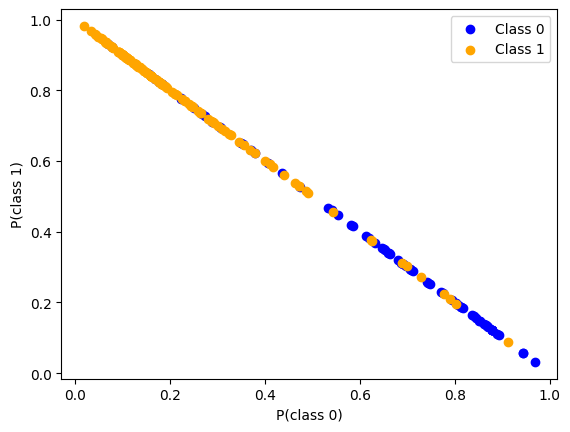


Final Evaluation Results with Best Parameters:
Individual fold accuracies: ['0.77', '0.86', '0.86', '0.91', '0.76', '0.62', '0.76', '0.71', '0.67', '0.71']
Mean Accuracy: 0.76 ± 0.09
Accuracy Range: 0.62 - 0.91


In [5]:
from scipy.optimize import minimize

def objective(params, X, y):
    C, gamma = params
    # Build pipeline with current C and gamma
    pipeline = make_pipeline(
        StandardScaler(),
        VarianceThreshold(threshold=0.1),
        CorrelationFilter(threshold=0.9),
        SVC(probability=True, C=C, gamma=gamma)
    )
    pipeline.fit(X, y)
    Q = pipeline.predict_proba(X)
    Q0, Q1 = Q[:, 0], Q[:, 1]
    Q0C0, Q0C1 = Q0[y == 0], Q0[y == 1]
    # Certainty: higher is better
    certainty_C0 = mean_distance_to_C0(Q0C0)
    certainty_C1 = 1 - mean_distance_to_C0(Q0C1)
    # Spread: higher is better
    spread_C0 = mean_distance_between_Q0s(Q0C0)
    spread_C1 = mean_distance_between_Q0s(Q0C1)
    # Negative sum to maximize all
    return -(certainty_C0 + certainty_C1 + spread_C0 + spread_C1)

# Initial guess: C=1, gamma=0.1
x0 = [1.0, 0.1]
bounds = [(0.1, 10), (0.01, 5)]

result = minimize(objective, x0, args=(X, y), bounds=bounds, method='L-BFGS-B')

best_C, best_gamma = result.x
print(f"\nBest C: {best_C:.4f}, Best gamma: {best_gamma:.4f}")

# Fit and plot with best parameters
svm_pipeline = make_pipeline(
    StandardScaler(),
    VarianceThreshold(threshold=0.1),
    CorrelationFilter(threshold=0.9),
    SVC(probability=True, C=best_C, gamma=best_gamma)
)
svm_pipeline.fit(X, y)
Q = svm_pipeline.predict_proba(X)
Q0, Q1 = Q[:, 0], Q[:, 1]
plot_likelihood_space(Q0, Q1, y)

# Final evaluation with best parameters
scores = cross_val_score(svm_pipeline, X, y, cv=cv, n_jobs=-1)
print("\nFinal Evaluation Results with Best Parameters:")
print(f"Individual fold accuracies: {[f'{s:.2f}' for s in scores]}")
print(f"Mean Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")
print(f"Accuracy Range: {scores.min():.2f} - {scores.max():.2f}")